# Focus on INV identified on Chrom 6

## I. Input


In [3]:

Chr= 6

genotype, summary, Names, RG_info= pretty_input(Chr= Chr)


{'fileformat': 'VCFv4.2', 'fileDate': '20190327', 'source': 'PLINKv1.90', 'contig': '<ID6,length31207416>', 'INFO': '<IDPR,Number0,TypeFlag,Description"Provisional reference allele, may not be based on real reference genome">', 'FORMAT': '<IDGT,Number1,TypeString,Description"Genotype">'}
Number of markers: 15000
Number of individuals: 3023


In [4]:

RG_info.head()

,IRIS_ID,NAME,Variety_Name_verif,COUNTRY,REGION,K9_cluster,Initial_subpop
0,B001,HEIBIAO,Heibiao,China,As6,GJ-tmp,temp
1,B002,SANSUIJIN,Sansuijin,China,As6,GJ-tmp,temp
2,B003,ZAOSHENGBAI,Zaoshengbai_,China,As6,GJ-adm,japx
3,B004,QIUGUANGTENGXI_104,Qiuguangtengxi_104_,Japan,As7,GJ-tmp,temp
4,B005,WANSHI,Wanshi,Japan,As7,GJ-tmp,temp


## II. Accessions of interest

Accessions to study the position of at different levels.


In [35]:

Names_select= ['IRIS_313-10834','IRIS_313-12289','IRIS_313-8580','IRIS_313-8872','IRIS_313-9048', ## Jap subtrops that carry INV
              'IRIS_313-10848','IRIS_313-12029','IRIS_313-12134','IRIS_313-12265','IRIS_313-8011', ## Jap subtrops that don't
              'B014', 'B002','B008','B023','B005'] ## Japonica temperate that carry INV.

    
Names_RG_info= [list(RG_info['IRIS_ID']).index(x) for x in Names_select]
Names_idx= [Names.index(x) for x in Names_select]


## III. Level 1 - across the Chromosome - Chromosome 6

### A. Among the 3K

- Includes cBas, cAus, Indica and Japonica groups

In [11]:

ID_col= 'IRIS_ID'
subset_col= 'Initial_subpop'


In [18]:
from tools.pretty tools import plot_interest
from dict_codes import (
    code, gp_cols, gp_ref_cols, gp_names_dict
) 
ref_keep= [0,1,2,3,5,6]

plot_interest(genotype, summary, RG_info, subset_col, Names, code= code, gp_names_dict= gp_names_dict,ref_keep= ref_keep,
                                                    include= Names_select, Sn= Sn, Sm= Sm, gp_cols= gp_ref_cols, sample= True)


15/15 of requested names present.
gen_sample shape: 413, 5000


Interest group and both control groups cluster with the Japonica. No apparent mislabelling at this level. 

### B. Positions among the Japonica.

Focusing on Japonica accessions, highlighting Japonica subtstructure.

In [19]:
from sklearn.decomposition import PCA


ref_keep= [2,5,6]

###

plot_interest(genotype, summary, RG_info, subset_col, Names, code= code, gp_names_dict= gp_names_dict,ref_keep= ref_keep,
                                                    include= Names_select, Sn= Sn, Sm= Sm, gp_cols= gp_cols, sample= True)


15/15 of requested names present.
gen_sample shape: 411, 5000


### C. Classification

Using KDE to classify local haplotypes relative to certain groups of choice. Here we chose the Japonica temperate, tropical and subtropical groups as references.

We classify haplotypes across chrom 6 for interest and control groups. 

In [97]:
color_lookup = {
    'red': [0,128,0],
    'yellow': [65,105,225],
    'blue': [128,0,128],
    'orange': [211, 211, 211],
    'green': [211, 211, 211],
    'black': [0, 0, 0],
    'purple': [211, 211, 211],
    'silver': [211, 211, 211],
}

adding ideograms...


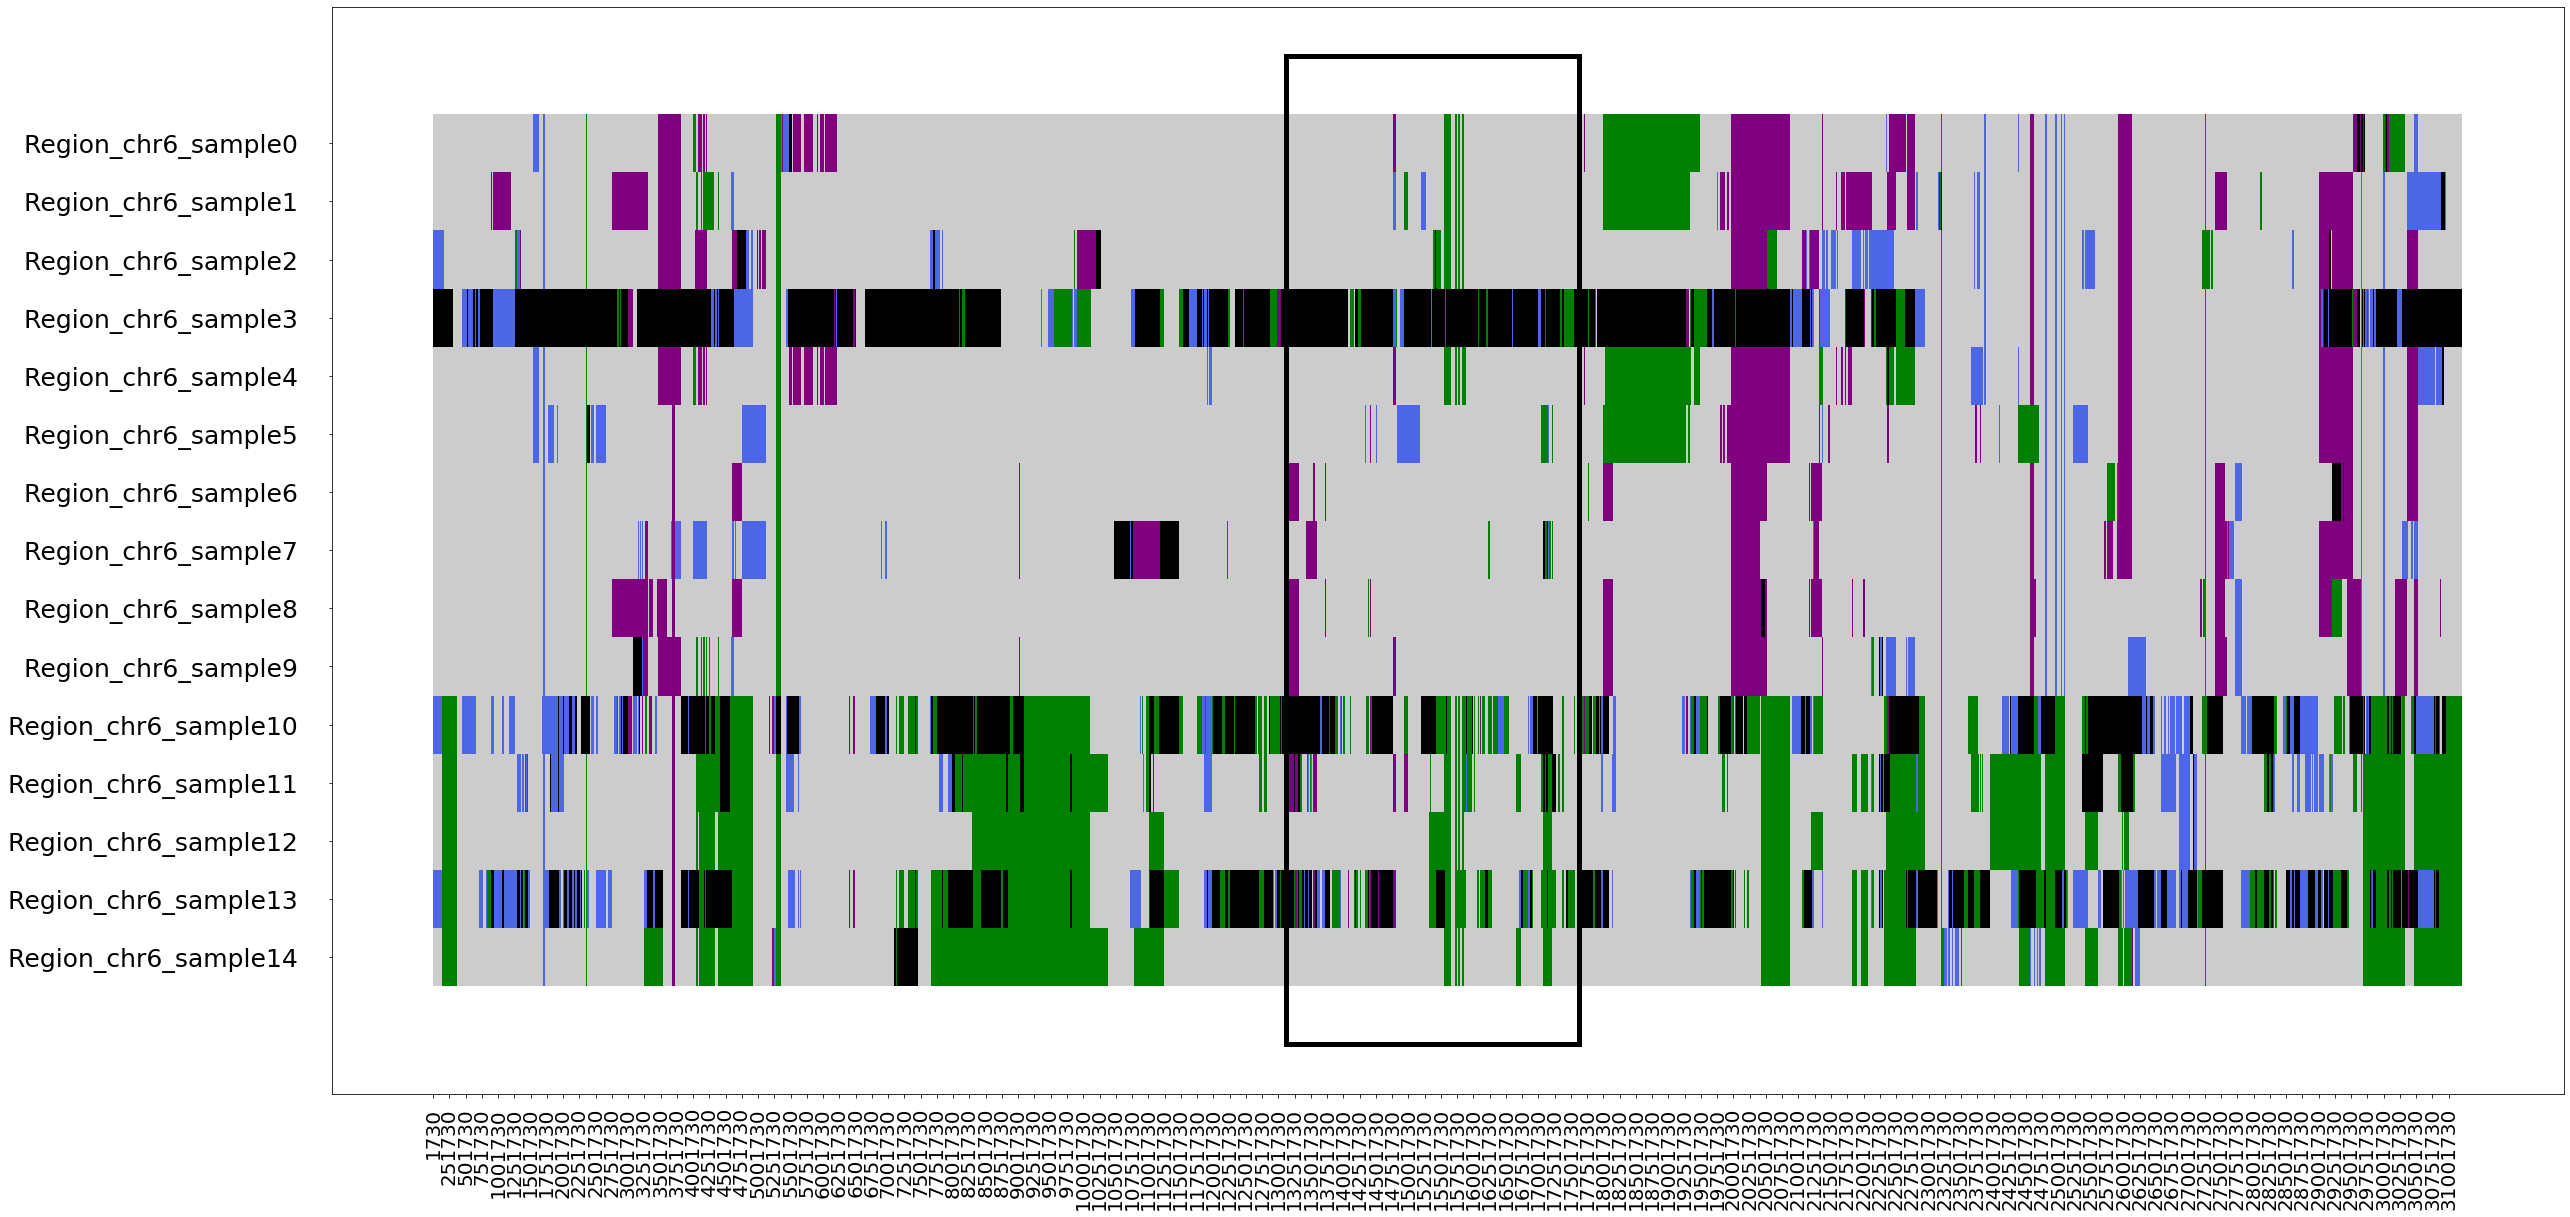

In [99]:
from tools.KDE_tools import KDE_window_profiles

## Use result of MS classification.

ref_labels= [2,5,6]

## 
id_tag= 'REGref_Struct'
subset= [13119682,17632495]

quick_kdeClass(genotype, summary,Names_idx,RG_info, Chr= Chr,subset= subset, 
               ref_labels= ref_labels,id_tag= id_tag, color_lookup= color_lookup,
               square= True, start= subset[0],end= subset[1])


Classification ideogram. Square indicates INV coordinates.

## IV. Closing in on the inversion.

We run the same two step analysis focusing the inversion region. 

coordinates below. 

In [20]:
subset= [13119682,17632495]

genotype, summary= subset_input(genotype, summary, subset= subset)

### A. Japonica structure within INV.

In [29]:
from sklearn.decomposition import PCA

ref_keep= [2,5,6]


plot_interest(genotype, summary, RG_info, subset_col, Names, code= code, gp_names_dict= gp_names_dict,ref_keep= ref_keep,
                                                    include= Names_select, Sn= Sn, Sm= Sm, gp_cols= gp_cols, sample= False)


### B. KDE Classification across INV

adding ideograms...


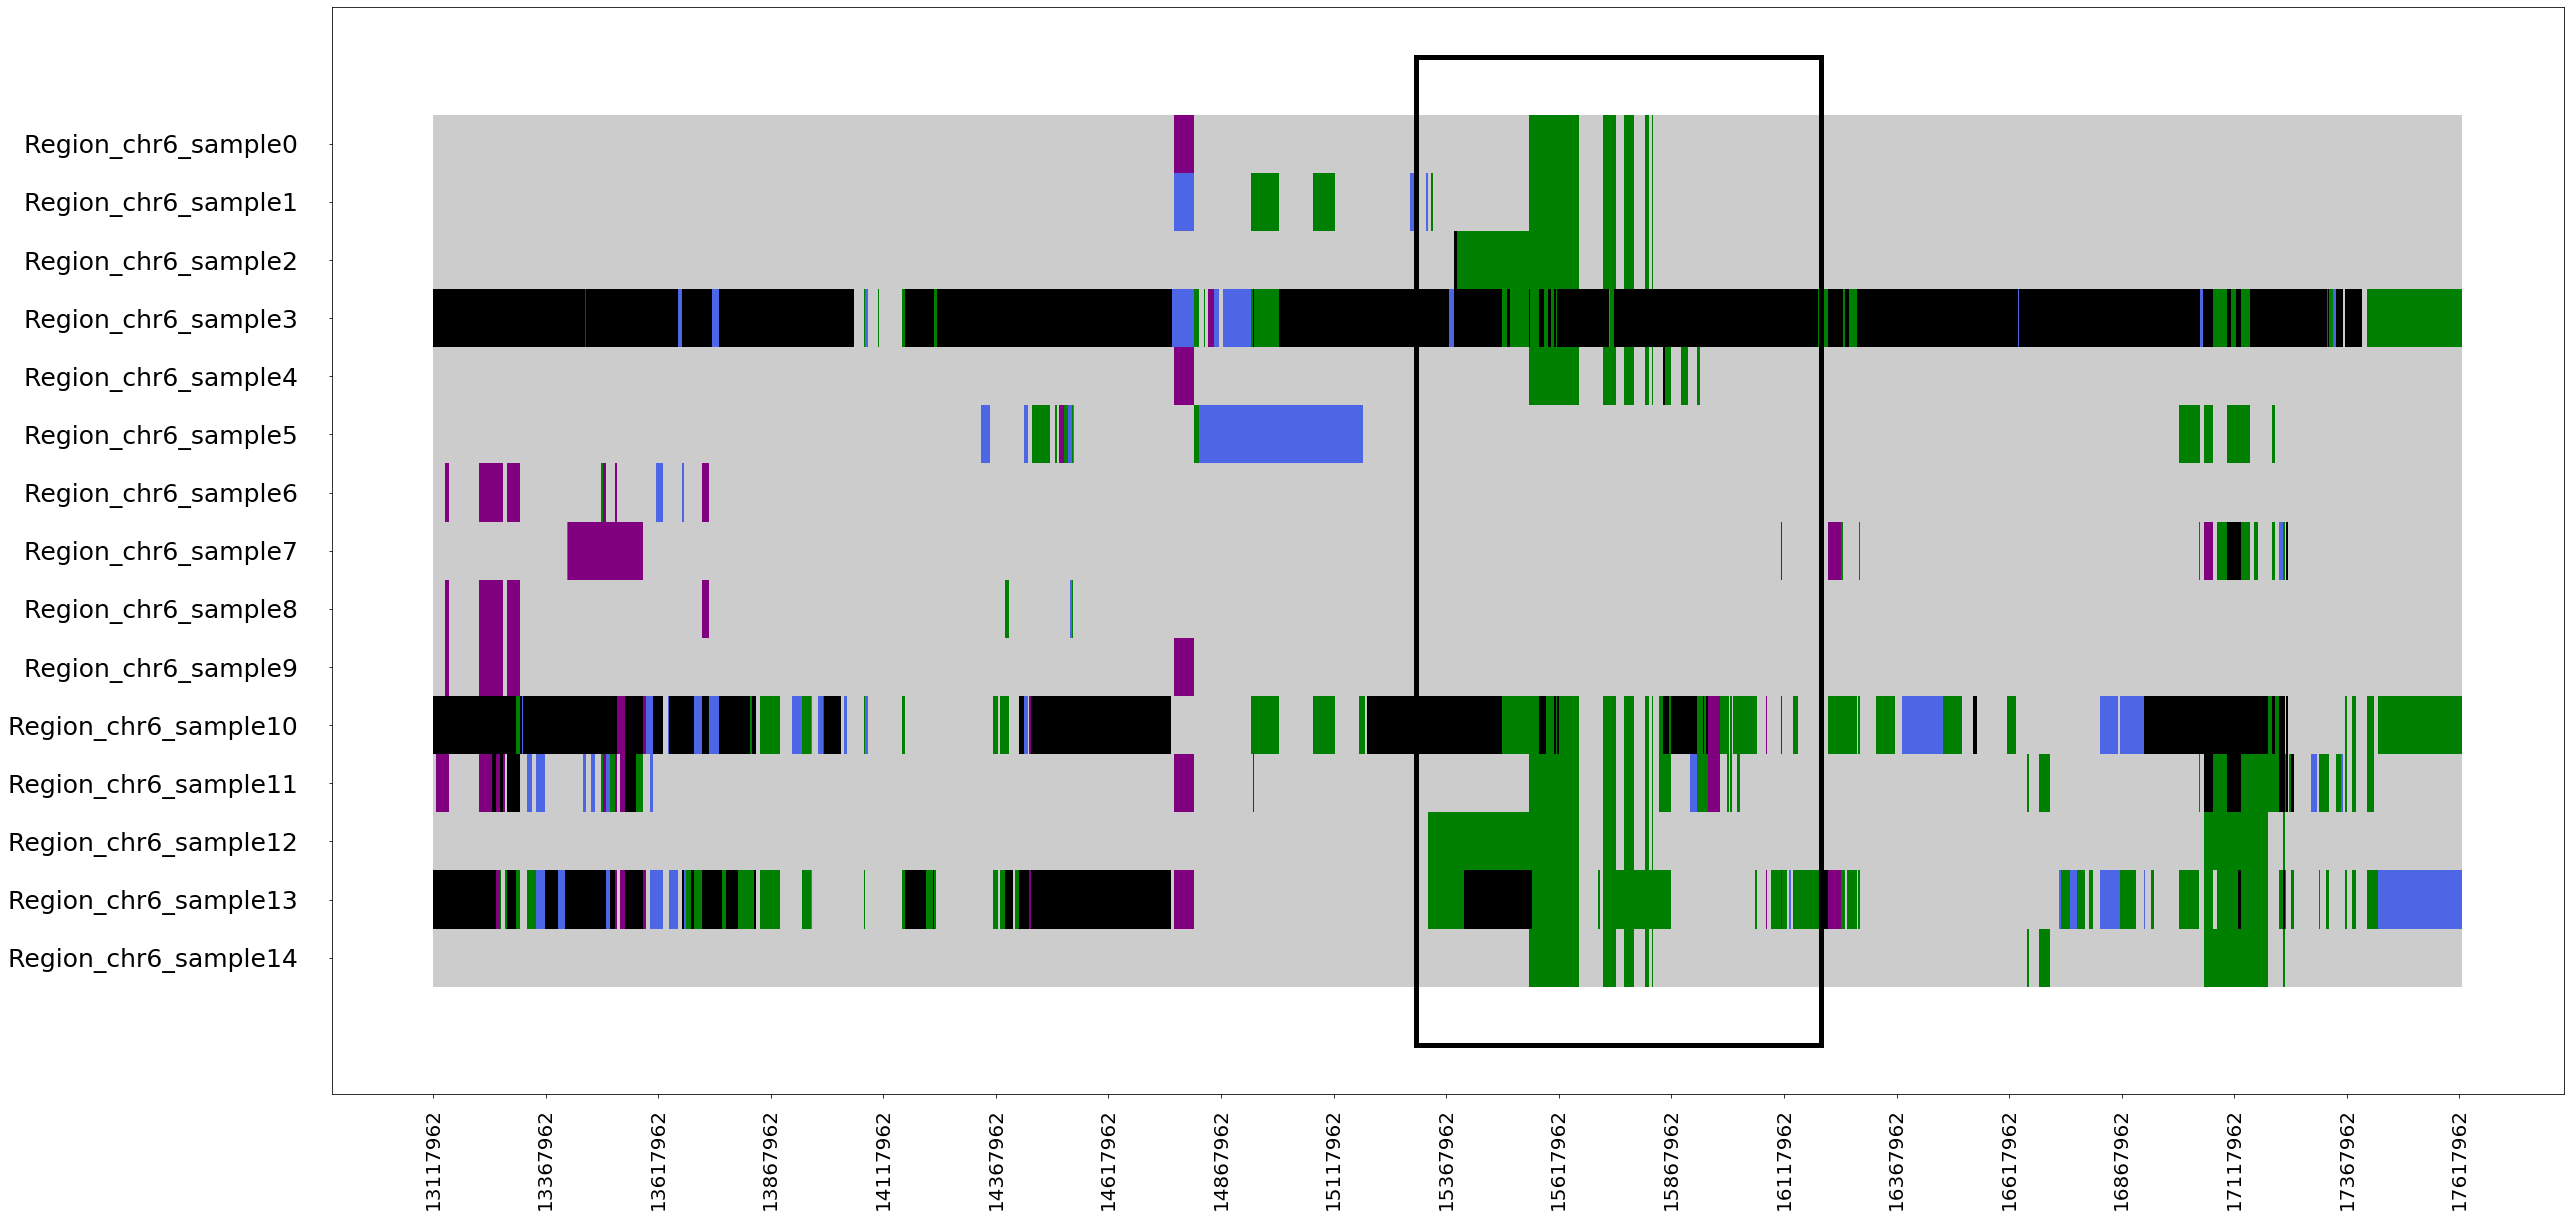

In [113]:
ref_labels= [2,5,6]

id_tag= 'INV_Struct'
subset= [15300000,16200000]

quick_kdeClass(genotype, summary,Names_idx,RG_info, Chr= Chr,subset= subset, 
               ref_labels= ref_labels,id_tag= id_tag, color_lookup= color_lookup,
               square= True, start= subset[0],end= subset[1])


**Ideogram across INV** Square highlights region that discriminates INV carrying accessions.

## V. Focusing on discriminant region.

Principal component analysis focusing on INV discriminant region.

In [30]:
subset= [15300000,16200000]

genotype, summary= subset_input(genotype, summary, subset= subset)


In [32]:

plot_interest(genotype, summary, RG_info, subset_col, Names, code= code, gp_names_dict= gp_names_dict,ref_keep= ref_keep,
                                                    include= Names_select, Sn= Sn, Sm= Sm, gp_cols= gp_cols, sample= False)
